# Pandas 相关性分析

相关性分析是数据分析中常见且重要的一步，它帮助我们理解数据中不同变量之间的关系。

在 Pandas 中，数据相关性分析是通过计算不同变量之间的相关系数来了解它们之间的关系。

在 Pandas 中，数据相关性是一项重要的分析任务，它帮助我们理解数据中各个变量之间的关系。

Pandas 提供了多种方法来计算和分析数据的相关性，常见的相关性方法包括皮尔逊相关系数（Pearson）、斯皮尔曼等级相关系数（Spearman）以及肯德尔秩相关系数（Kendall）。

以下相关性方法可以帮助我们揭示变量之间的线性关系、非线性关系或单调关系：

- **皮尔逊相关系数**：衡量变量之间的线性关系，适用于数值型变量。
- **斯皮尔曼等级相关系数**：衡量变量之间的单调关系，适用于数值型和顺序型变量。
- **肯德尔秩相关系数**：衡量变量之间的秩次关系，适用于小样本数据。
- **相关性矩阵**：用来查看各个变量之间的相关性。
- **热图**：一种有效的可视化方式，可以帮助我们直观地查看变量之间的相关性。

## 什么是相关性？

相关性表示两个或多个变量之间的关系强度和方向。根据相关性的数值，可以判断变量之间的关系。

- **正相关**：当一个变量增加时，另一个变量也增加。例如，身高和体重之间可能存在正相关关系。
- **负相关**：当一个变量增加时，另一个变量减少。例如，气温和取暖的使用量之间可能存在负相关关系。
- **无相关性**：两个变量之间没有明确的关系。

相关性的数值范围通常在 -1 到 1 之间：

- **1**：完全正相关
- **-1**：完全负相关
- **0**：没有线性相关性
- **接近 1 或 -1**：表示强相关
- **接近 0**：表示弱相关

## Pandas 中计算相关性的方法

Pandas 提供了 DataFrame.corr() 和 DataFrame.cov() 方法来计算相关性和协方差。

Pandas 使用 corr() 方法计算数据集中每列之间的关系。

```
df.corr(method='pearson', min_periods=1)
```

参数说明：

- **method (可选)**: 字符串类型，用于指定计算相关系数的方法。默认是 'pearson'，还可以选择 'kendall'（Kendall Tau 相关系数）或 'spearman'（Spearman 秩相关系数）。

- **min_periods (可选)**: 表示计算相关系数时所需的最小观测值数量。默认值是 1，即只要有至少一个非空值，就会进行计算。如果指定了 min_periods，并且在某些列中的非空值数量小于该值，则相应列的相关系数将被设为 NaN。

df.corr() 方法返回一个相关系数矩阵，矩阵的行和列对应数据框的列名，矩阵的元素是对应列之间的相关系数。

常见的相关性系数包括 Pearson 相关系数和 Spearman 秩相关系数：

### Pearson 相关系数

Pearson 即皮尔逊相关系数，用于衡量了两个变量之间的线性关系强度和方向，它的取值范围在 -1 到 1 之间，其中 -1 表示完全负相关，1 表示完全正相关，0 表示无线性相关。

皮尔逊相关系数用于衡量两个变量之间的线性关系，计算公式为：

皮尔逊相关系数用于衡量两个变量之间的线性关系，计算公式为：

r = Σ[(xi - x̄)(yi - ȳ)] / √[Σ(xi - x̄)²Σ(yi - ȳ)²]

其中：
- r 是皮尔逊相关系数
- xi, yi 是两个变量的观测值
- x̄, ȳ 是两个变量的平均值
- Σ 表示求和

皮尔逊相关系数的特点：

- **取值范围**：-1 到 1 之间
- **完全正相关**：r = 1
- **完全负相关**：r = -1
- **无线性相关**：r = 0
- **强相关**：|r| ≥ 0.7
- **中等相关**：0.3 ≤ |r| < 0.7
- **弱相关**：|r| < 0.3

使用 Pandas 计算皮尔逊相关系数：

```python
df.corr(method='pearson')
```

Pandas 可以使用 corr() 方法计算数据框中各列之间的 Pearson 相关系数。

Pandas 可以使用 corr() 方法计算数据框中各列之间的 Pearson 相关系数.

In [23]:
# 实例
import pandas as pd

# 示例数据
data = {
    'Height': [150, 160, 170, 180, 190],
    'Weight': [45, 55, 65, 75, 85],
    'Age': [20, 25, 30, 35, 40]
}
df = pd.DataFrame(data)

# 计算皮尔逊相关系数
correlation = df.corr(method="pearson")
print(correlation)

# 说明:

# corr() 方法计算了每对变量之间的皮尔逊相关系数。method='pearson' 是默认方法，表示计算皮尔逊相关系数。
# 可以看到，Height 与 Weight 和 Age 都有很强的正相关性。


        Height  Weight  Age
Height     1.0     1.0  1.0
Weight     1.0     1.0  1.0
Age        1.0     1.0  1.0


### Spearman 秩相关系数
 
Spearman 秩相关系数（Spearman Correlation）是一种非参数方法，用于衡量两个变量之间的单调关系，不假设数据服从特定分布。它基于变量的秩次而非原始值。
 
斯皮尔曼相关系数用于衡量两个变量的单调关系（无论是线性还是非线性），它是基于变量的排名计算的。斯皮尔曼相关系数的取值范围与皮尔逊相关系数相同：-1 到 1。
 

In [24]:
# 示例数据
data = {
    'Height': [150, 160, 170, 180, 160],
    'Weight': [45, 55, 65, 75, 85],
    'Age': [20, 25, 30, 35, 40]
}

df = pd.DataFrame(data)

# 计算斯皮尔曼等级相关系数
spearman_correlation = df.corr(method='spearman')
print(spearman_correlation)

          Height    Weight       Age
Height  1.000000  0.564288  0.564288
Weight  0.564288  1.000000  1.000000
Age     0.564288  1.000000  1.000000


### Kendall 秩相关系数
 
肯德尔秩相关系数（Kendall Correlation）也用于衡量变量之间的单调关系，它是通过计算两个变量排名之间的一致性来得出的。
 
肯德尔相关系数的计算较为复杂，适用于较小的数据集。
 

In [25]:
# 示例数据
data = {
    'Height': [150, 160, 170, 180, 160],
    'Weight': [45, 55, 65, 75, 85],
    'Age': [20, 25, 30, 35, 40]
}

df = pd.DataFrame(data)

kendall_correlation = df.corr(method = 'kendall')
print(kendall_correlation)

          Height    Weight       Age
Height  1.000000  0.527046  0.527046
Weight  0.527046  1.000000  1.000000
Age     0.527046  1.000000  1.000000


### 相关性矩阵
相关性矩阵是一个对称矩阵，矩阵中的每个值表示两个变量之间的相关系数。

可以通过 corr() 方法直接计算 DataFrame 中所有变量的相关性矩阵。

In [26]:
data = {
    'Height': [150, 160, 170, 180, 160],
    'Weight': [45, 55, 65, 75, 85],
    'Age': [20, 25, 30, 35, 40]
}

df = pd.DataFrame(data)

correlation = df.corr()
print(correlation)

# 说明：相关性矩阵可以帮助我们快速识别出哪些变量之间有较强的线性或单调关系。在实际分析中，相关性矩阵对于特征选择和降维非常有帮助。

        Height  Weight     Age
Height  1.0000  0.5547  0.5547
Weight  0.5547  1.0000  1.0000
Age     0.5547  1.0000  1.0000


### 相关性热图（Correlation Heatmap）
为了更直观地呈现相关性矩阵，可以使用热图（Heatmap）来可视化各个变量之间的相关性。

使用 seaborn 库绘制相关性热图是一个常见的做法。

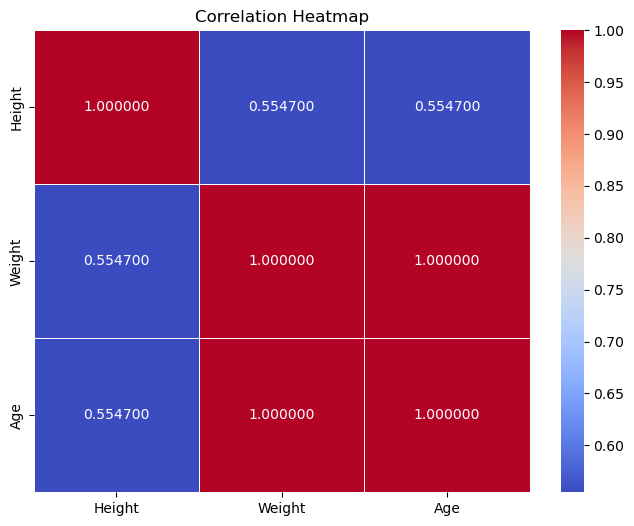

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# 示例数据
data = {
    'Height': [150, 160, 170, 180, 160],
    'Weight': [45, 55, 65, 75, 85],
    'Age': [20, 25, 30, 35, 40]
}

df = pd.DataFrame(data)

# 计算相关性矩阵
correlation = df.corr()

# 绘制相关性热图
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".6f", linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()
# 说明：sns.heatmap() 绘制相关性热图，annot=True 表示在热图上显示数值，cmap='coolwarm' 设置颜色范围，vmin=-1, vmax=1 限制颜色范围为 -1 到 1。


### 相关性分析中的应用
#### 1、特征选择
在机器学习建模中，相关性分析常常用于特征选择。通过分析不同特征之间的相关性，可以帮助我们选择与目标变量最相关的特征，并去除与其他特征高度相关的冗余特征，从而提高模型的表现和效率。

#### 2、处理多重共线性
如果两个或多个特征之间的相关性非常高（接近 1 或 -1），那么这些特征之间存在多重共线性问题。在回归分析中，多重共线性会导致模型的不稳定性和预测不准确。可以通过删除或合并相关性较高的特征来解决多重共线性问题。